In [20]:
import numpy as np
import sys
import matplotlib.pyplot as plt
import torch
import torch_geometric
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, EdgeConv, DynamicEdgeConv
from torcheval.metrics import MulticlassAUROC, MulticlassAccuracy


sys.path.append("../")

In [21]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [22]:
DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR = "../models"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_mppc_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_mppc_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)
sig_only_pixel_spacetime = np.load(SIGNAL_ONLY_PIXEL_FILE)
sig_only_mppc_spacetime = np.load(SIGNAL_ONLY_MPPC_FILE)



In [23]:
sig_only_pixel_time = sig_only_pixel_spacetime[:,:, -1]
sig_only_mppc_time = sig_only_mppc_spacetime[:,:, -1]

In [29]:
pixel_time_range = np.zeros(len(sig_only_pixel_spacetime))
for event_id in range(len(sig_only_pixel_spacetime)):
    if np.all(sig_only_pixel_time[event_id] == -1):
        pixel_time_range[event_id] = -1
        continue
    pixel_time_range[event_id] = (
        np.max(sig_only_pixel_time[event_id][sig_only_pixel_time[event_id] != -1])
        - np.min(sig_only_pixel_time[event_id][sig_only_pixel_time[event_id] != -1]
    ))
num_pixel_hits = np.sum(sig_only_pixel_time != -1, axis=1)

(array([14.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 12.]),
 array([ 0. ,  5.6, 11.2, 16.8, 22.4, 28. , 33.6, 39.2, 44.8, 50.4, 56. ]),
 <BarContainer object of 10 artists>)

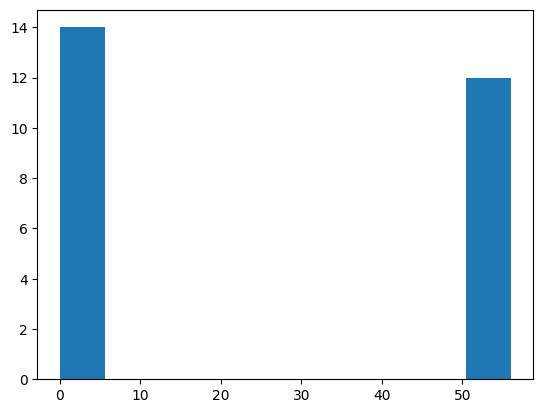

In [51]:
plt.hist(sig_only_pixel_time[pixel_time_range == 56][1][sig_only_pixel_time[pixel_time_range == 56][1] != -1])

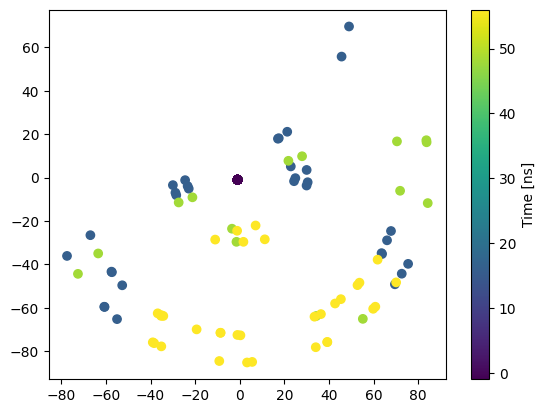

In [ ]:
plt.scatter(sig_only_pixel_spacetime[pixel_time_range > 16, :, 0][0], sig_only_pixel_spacetime[pixel_time_range > 16, :, 1][0], c = sig_only_pixel_time[pixel_time_range > 16][0])

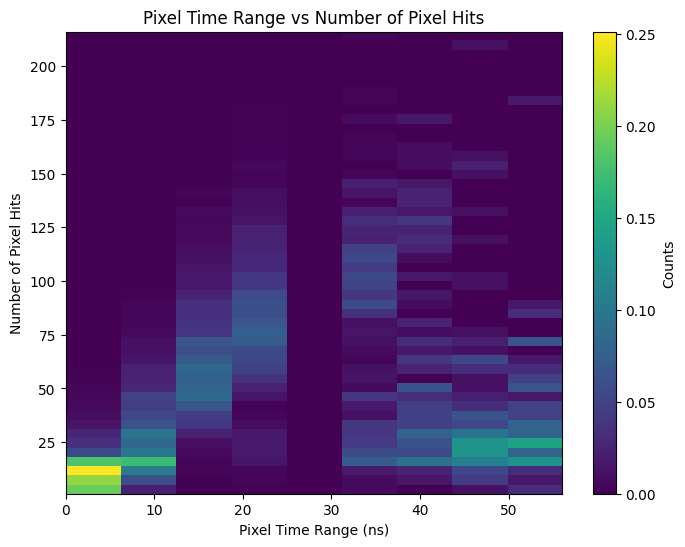

In [38]:
hist, x_edges, y_edges = np.histogram2d(
    pixel_time_range[num_pixel_hits > 0],
    num_pixel_hits[num_pixel_hits > 0],
    bins = (9, 50)
)
hist /= (np.sum(hist, axis=1, keepdims=True) +1e-1) # Normalize each column

plt.figure(figsize=(8,6))
plt.imshow(hist.T, origin='lower', aspect='auto',
           extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
           cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('Pixel Time Range (ns)')
plt.ylabel('Number of Pixel Hits')
plt.title('Pixel Time Range vs Number of Pixel Hits')
plt.show()